In [2]:
from datasets.fire_dataset import val_dataset, train_dataset, test_dataset

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [4]:
from models.CONVLSTM import ConvLSTM, ConvLSTM2Layers

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Model Visualization

In [6]:
model = ConvLSTM().to(device=device)
model.load_state_dict(torch.load("saved_models/ConvLSTM_3v_45_checkpoint.pt")["model"])

<All keys matched successfully>

In [7]:
min_lat, max_lat = -55.0, 82.0
min_lon, max_lon = -179.0, 179.5


In [29]:
def show_heatmap_over_n_days(generated_map: np.ndarray | torch.Tensor,  
                 coords: list, figure_size: list = [10, 5], color_map: str= "hot", roll: int | None = None):
    assert len(generated_map.shape) == 4
    assert isinstance(coords, list) or isinstance(coords, tuple) or coords == None  
    
    # dimensions to show
    min_lat, max_lat = coords[0]
    min_lon, max_lon = coords[1]
        
    # prepare map
    n_lat = generated_map.shape[2]
    n_lon = generated_map.shape[3]
    
    # horizontal shift
    if roll != None:
        generated_map = np.roll(generated_map, shift=roll, axis=-1)
    
    lat_edges = np.linspace(min_lat, max_lat, n_lat + 1)
    lon_edges = np.linspace(min_lon, max_lon, n_lon + 1)

    lat_mask = (lat_edges >= min_lat) & (lat_edges <= max_lat) 
    lon_mask = (lon_edges >= min_lon) & (lon_edges <= max_lon)

    lat_indices = np.where(lat_mask)[0]
    lon_indices = np.where(lon_mask)[0]

    if len(lat_indices) == 0 or len(lon_indices) == 0:
        raise ValueError("Coordinate bounds do not intersect with data grid")
    
    lat_slice = slice(lat_indices[0], lat_indices[-1]+1)
    lon_slice = slice(lon_indices[0], lon_indices[-1]+1)

    generated_map_zoomed = generated_map[:, :, lat_slice, lon_slice]
    lat_zoomed = lat_edges[lat_slice]
    lon_zoomed = lon_edges[lon_slice]

    lon_grid, lat_grid = np.meshgrid(lon_zoomed, lat_zoomed)
    
    fig = plt.figure(figsize=figure_size)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='gray', linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    pcm = ax.pcolormesh(
        lon_grid, lat_grid,
        generated_map_zoomed[0, 0],
        cmap=color_map,
        shading='auto',
        alpha=0.7,vmin=-0.1, vmax= 2.5,           
        transform=ccrs.PlateCarree()
    )
    plt.colorbar(pcm, ax=ax, label='Predicted Value')
    plt.show()

    return generated_map_zoomed, (lat_zoomed, lon_zoomed), pcm, fig

In [9]:
def make_predictions(X, n_days: int) -> np.ndarray:
    X_input = X.to(device)  # Move input tensor to the same device as the model
    predictions = []
    model.eval()
    with torch.no_grad():
        for day in range(n_days):
            Y_pred = model(X_input)
            predictions.append(Y_pred.cpu().numpy())
            X_input = torch.cat([X_input[:, 1:], Y_pred.unsqueeze(1)], dim=1)
    return np.concatenate(predictions, axis=0)


In [46]:
X, Y = train_dataset[1]

In [11]:
X.unsqueeze(0).dtype

torch.float32

In [47]:
criterion = nn.MSELoss()

In [57]:
y_pred_np = make_predictions(X[:3].unsqueeze(0), 4)

y_pred_tensor = torch.tensor(y_pred_np, device=device, dtype=torch.float32)

y_true_tensor = Y.unsqueeze(0).to(device).float()

loss = criterion(y_pred_tensor, y_true_tensor)

/home/clyde/anaconda3/envs/self-driving-cars/lib/python3.12/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1, 269, 687])) that is different to the input size (torch.Size([4, 1, 269, 687])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [35]:
def update(frame, generated_map_zoomed, pcm, title=None):
   
    data = generated_map_zoomed[frame, 0]
    pcm.set_array(data.ravel())  
    
    if title is not None:
        title.set_text(f"Day {frame + 1} Prediction")
        return [pcm, title]
    else:
        return [pcm]


In [36]:
true_map_zoomed

array([[[[-0.11446705, -0.11446705, -0.11446705, ..., -0.11446705,
          -0.11446705, -0.11446705],
         [-0.11446705, -0.11446705, -0.11446705, ..., -0.11446705,
          -0.11446705, -0.11446705],
         [-0.11446705, -0.11446705, -0.11446705, ..., -0.11446705,
          -0.11446705, -0.11446705],
         ...,
         [-0.11446705, -0.11446705, -0.11446705, ..., -0.11446705,
          -0.11446705, -0.11446705],
         [-0.11446705, -0.11446705, -0.11446705, ..., -0.11446705,
          -0.11446705, -0.11446705],
         [-0.11446705, -0.11446705, -0.11446705, ..., -0.11446705,
          -0.11446705, -0.11446705]]]], dtype=float32)

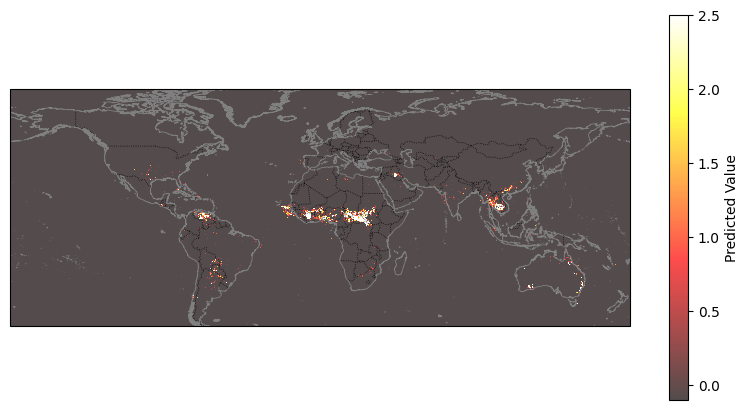

In [58]:
true_map_zoomed, (true_lat_zoomed, true_lon_zoomed), tpcm, tAx = show_heatmap_over_n_days(X[3:], 
                                                                                          coords=[(min_lat, max_lat), (min_lon, max_lon)],
                                                                                         roll=5)

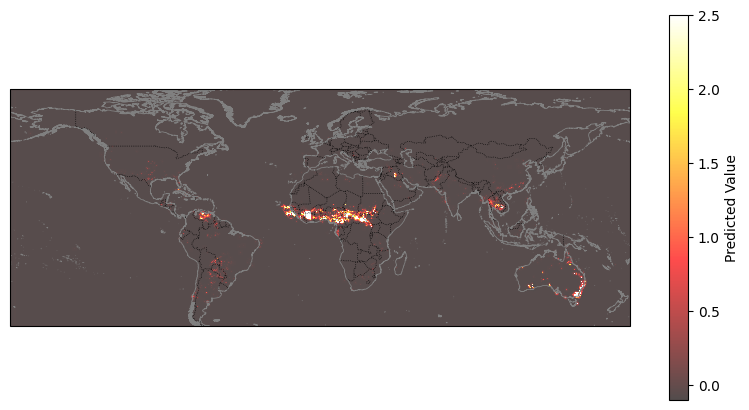

In [59]:
pred_map_zoomed, (pred_lat_zoomed, pred_lon_zoomed), ppcm, pAx = show_heatmap_over_n_days(y_pred_np, 
                                                                                          coords=[(min_lat, max_lat), (min_lon, max_lon)],
                                                                                         roll=5)

In [60]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# after setting up your plot:

anim = FuncAnimation(
    tAx, update, 
    frames=true_map_zoomed.shape[0], 
    fargs=(true_map_zoomed, tpcm),
    interval=500, blit=False
)
HTML(anim.to_jshtml())


In [61]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# after setting up your plot:

anim = FuncAnimation(
    pAx, update, 
    frames=pred_map_zoomed.shape[0], 
    fargs=(pred_map_zoomed, ppcm),
    interval=500, blit=False
)
HTML(anim.to_jshtml())
